# MVP UI Demo: Full Cycle Entry Point

Этот notebook — каноническая пользовательская точка входа поверх полного пайплайна `run_full_cycle` только по листу `"Общее"`.

- `MODE = "full"` — полное переобучение и пересборка артефактов.
- `MODE = "fast"` — повторный запуск с уже сохраненной моделью.

Базовый сценарий: `Restart Kernel` -> `Run All`.


In [1]:
from pathlib import Path

def find_project_root(start: Path) -> Path:
    for candidate in [start, *start.parents]:
        if (candidate / "pyproject.toml").exists() and (candidate / "src").exists():
            return candidate
    raise FileNotFoundError("Project root not found (expected pyproject.toml and src/).")

PROJECT_ROOT = find_project_root(Path.cwd())
INPUT_PATH = PROJECT_ROOT / "data" / "raw" / "episodes.xlsx"
OUTPUT_DIR = PROJECT_ROOT / "artifacts" / "demo_run"
MODEL_PATH = OUTPUT_DIR / "models" / "hmm_model.pkl"

SHEET_NAMES = ["Общее"]
HEADER_DEPTH = 4
MODE = "full"  # "full" | "fast"

print(f"PROJECT_ROOT: {PROJECT_ROOT}")
print(f"INPUT_PATH: {INPUT_PATH}")
print(f"OUTPUT_DIR: {OUTPUT_DIR}")
print(f"MODEL_PATH: {MODEL_PATH}")
print(f"SHEET_NAMES: {SHEET_NAMES}")
print(f"HEADER_DEPTH: {HEADER_DEPTH}")
print(f"MODE: {MODE}")

if not INPUT_PATH.exists():
    raise FileNotFoundError(f"Input Excel not found: {INPUT_PATH}")


PROJECT_ROOT: /Users/dmitryaleshkin/Documents/hidden-patterns-combat
INPUT_PATH: /Users/dmitryaleshkin/Documents/hidden-patterns-combat/data/raw/episodes.xlsx
OUTPUT_DIR: /Users/dmitryaleshkin/Documents/hidden-patterns-combat/artifacts/demo_run
MODEL_PATH: /Users/dmitryaleshkin/Documents/hidden-patterns-combat/artifacts/demo_run/models/hmm_model.pkl
SHEET_NAMES: ['Общее']
HEADER_DEPTH: 4
MODE: full


In [2]:
# Optional: ручная очистка перед полным прогоном.
# По умолчанию удаление отключено, чтобы `Run All` был безопасным.

import shutil

RUN_CLEANUP = False  # Переключите в True и запустите ячейку вручную при необходимости

if RUN_CLEANUP:
    if OUTPUT_DIR.exists():
        shutil.rmtree(OUTPUT_DIR)
        print(f"Removed: {OUTPUT_DIR}")
    else:
        print(f"Nothing to remove: {OUTPUT_DIR}")
else:
    print("Cleanup skipped (RUN_CLEANUP=False).")


Cleanup skipped (RUN_CLEANUP=False).


In [3]:
from hidden_patterns_combat.app.full_cycle import run_full_cycle

result = run_full_cycle(
    input_path=INPUT_PATH,
    output_dir=OUTPUT_DIR,
    sheet_names=SHEET_NAMES,
    header_depth=HEADER_DEPTH,
    mode=MODE,
    model_path=MODEL_PATH,
)

result.as_dict()


[1/8] Preprocessing Excel input... requested_sheets=['Общее']
      loaded_sheets=['Общее']
[2/8] Feature engineering...
[3/8] Preparing HMM sequences...
[4/8] Training/loading model...


HMM finished with negative monitor delta: delta=-0.136140 (possible local instability).


      convergence_note=negative final monitor delta; model may be in a local unstable optimum.
[5/8] Decoding hidden states and running analysis...
[6/8] Generating visualizations...
[7/8] Writing summary/report...
[8/8] Full cycle completed.


{'input_path': '/Users/dmitryaleshkin/Documents/hidden-patterns-combat/data/raw/episodes.xlsx',
 'output_dir': '/Users/dmitryaleshkin/Documents/hidden-patterns-combat/artifacts/demo_run',
 'requested_sheets': ['Общее'],
 'loaded_sheets': ['Общее'],
 'cleaned_data_path': '/Users/dmitryaleshkin/Documents/hidden-patterns-combat/artifacts/demo_run/cleaned/cleaned_tidy.csv',
 'features_path': '/Users/dmitryaleshkin/Documents/hidden-patterns-combat/artifacts/demo_run/features/engineered_feature_set.csv',
 'model_path': '/Users/dmitryaleshkin/Documents/hidden-patterns-combat/artifacts/demo_run/models/hmm_model.pkl',
 'report_path': '/Users/dmitryaleshkin/Documents/hidden-patterns-combat/artifacts/demo_run/reports/full_cycle_report.md',
 'plots_dir': '/Users/dmitryaleshkin/Documents/hidden-patterns-combat/artifacts/demo_run/plots',
 'diagnostics_path': '/Users/dmitryaleshkin/Documents/hidden-patterns-combat/artifacts/demo_run/diagnostics/hmm_state_interpretation.csv',
 'n_rows_raw': 967,
 'n_r

In [4]:
import pandas as pd
from IPython.display import Markdown, display

diagnostics_csv = OUTPUT_DIR / "diagnostics" / "hmm_state_interpretation.csv"
report_md = OUTPUT_DIR / "reports" / "full_cycle_report.md"

if diagnostics_csv.exists():
    print(f"Diagnostics: {diagnostics_csv}")
    display(pd.read_csv(diagnostics_csv))
else:
    print(f"Diagnostics file not found: {diagnostics_csv}")

if report_md.exists():
    print(f"Report: {report_md}")
    display(Markdown(report_md.read_text(encoding="utf-8")))
else:
    print(f"Report file not found: {report_md}")


Diagnostics: /Users/dmitryaleshkin/Documents/hidden-patterns-combat/artifacts/demo_run/diagnostics/hmm_state_interpretation.csv


,state_id,maneuver_right_code,maneuver_left_code,grips_code,holds_code,bodylocks_code,underhooks_code,posts_code,kfv_code,vup_code,outcome_actions_code,duration,pause,observed_result,episodes_count,state_name,raw_hidden_state,posthoc_interpretation
0,0,3.540872,1.690705,1.968300,0.130601,0.689388,0.504715,0.110865,8.887943,0.854219,0.202762,27.114558,13.978520,0.288783,419,state_0,state_0,Пост-хок: состояние характеризуется повышенной...
1,1,3.765984,1.184508,2.183859,0.217880,0.000000,0.000000,0.000000,2.987452,0.481961,0.250555,26.121324,8.992647,0.419118,272,S1,S1,Пост-хок: состояние смещено в сторону стойки/м...
2,2,3.261429,1.658554,1.723363,0.430377,0.881619,0.017417,0.160695,8.224305,0.745374,0.215523,23.260073,12.384615,0.282051,273,state_2,state_2,Пост-хок: состояние характеризуется повышенной...


Report: /Users/dmitryaleshkin/Documents/hidden-patterns-combat/artifacts/demo_run/reports/full_cycle_report.md


# Full Cycle Report

- Input file: `/Users/dmitryaleshkin/Documents/hidden-patterns-combat/data/raw/episodes.xlsx`
- Output dir: `/Users/dmitryaleshkin/Documents/hidden-patterns-combat/artifacts/demo_run`
- Requested sheets: `['Общее']`
- Loaded sheets: `['Общее']`
- Rows raw/clean: 967/964
- Engineered features: 11
- HMM input features: `['maneuver_right_code', 'maneuver_left_code', 'grips_code', 'holds_code', 'bodylocks_code', 'underhooks_code', 'posts_code', 'kfv_code', 'vup_code', 'duration', 'pause']`
- Dropped constant HMM features: `[]`
- HMM converged: True
- HMM iterations: 8
- HMM last delta: -0.13613959972389011
- Sequences: 94
- Model states: 3

## State Summary
- state=?, name=state_0, episodes=419, result_mean=0.2888
- state=?, name=S1, episodes=272, result_mean=0.4191
- state=?, name=state_2, episodes=273, result_mean=0.2821

## Sample Analysis
- {"episode_id": "1.0", "sequence_id": "Общее::Акрамов Б.Б.", "hidden_state": 0, "hidden_state_name": "state_0", "observed_result": 1.0, "probabilities": {"p_state_0": 1.0, "p_state_1": 0.0, "p_state_2": 0.0}}

## Artifacts
- `/Users/dmitryaleshkin/Documents/hidden-patterns-combat/artifacts/demo_run/cleaned/raw_combined.csv`
- `/Users/dmitryaleshkin/Documents/hidden-patterns-combat/artifacts/demo_run/cleaned/cleaned_tidy.csv`
- `/Users/dmitryaleshkin/Documents/hidden-patterns-combat/artifacts/demo_run/cleaned/data_dictionary.csv`
- `/Users/dmitryaleshkin/Documents/hidden-patterns-combat/artifacts/demo_run/cleaned/validation.json`
- `/Users/dmitryaleshkin/Documents/hidden-patterns-combat/artifacts/demo_run/features/raw_feature_set.csv`
- `/Users/dmitryaleshkin/Documents/hidden-patterns-combat/artifacts/demo_run/features/engineered_feature_set.csv`
- `/Users/dmitryaleshkin/Documents/hidden-patterns-combat/artifacts/demo_run/features/feature_traceability.csv`
- `/Users/dmitryaleshkin/Documents/hidden-patterns-combat/artifacts/demo_run/features/feature_validation.json`
- `/Users/dmitryaleshkin/Documents/hidden-patterns-combat/artifacts/demo_run/diagnostics/episode_analysis.csv`
- `/Users/dmitryaleshkin/Documents/hidden-patterns-combat/artifacts/demo_run/diagnostics/state_profile.csv`
- `/Users/dmitryaleshkin/Documents/hidden-patterns-combat/artifacts/demo_run/diagnostics/hmm_state_interpretation.csv`
- `/Users/dmitryaleshkin/Documents/hidden-patterns-combat/artifacts/demo_run/diagnostics/interpretation.txt`
- `/Users/dmitryaleshkin/Documents/hidden-patterns-combat/artifacts/demo_run/models/hmm_model.pkl`
- `/Users/dmitryaleshkin/Documents/hidden-patterns-combat/artifacts/demo_run/plots/athlete_comparative_profile.png`
- `/Users/dmitryaleshkin/Documents/hidden-patterns-combat/artifacts/demo_run/plots/hidden_state_sequence.png`
- `/Users/dmitryaleshkin/Documents/hidden-patterns-combat/artifacts/demo_run/plots/scenario_success_frequencies.png`
- `/Users/dmitryaleshkin/Documents/hidden-patterns-combat/artifacts/demo_run/plots/state_probability_profile.png`
- `/Users/dmitryaleshkin/Documents/hidden-patterns-combat/artifacts/demo_run/plots/transition_distribution.png`


Showing: /Users/dmitryaleshkin/Documents/hidden-patterns-combat/artifacts/demo_run/plots/hidden_state_sequence.png


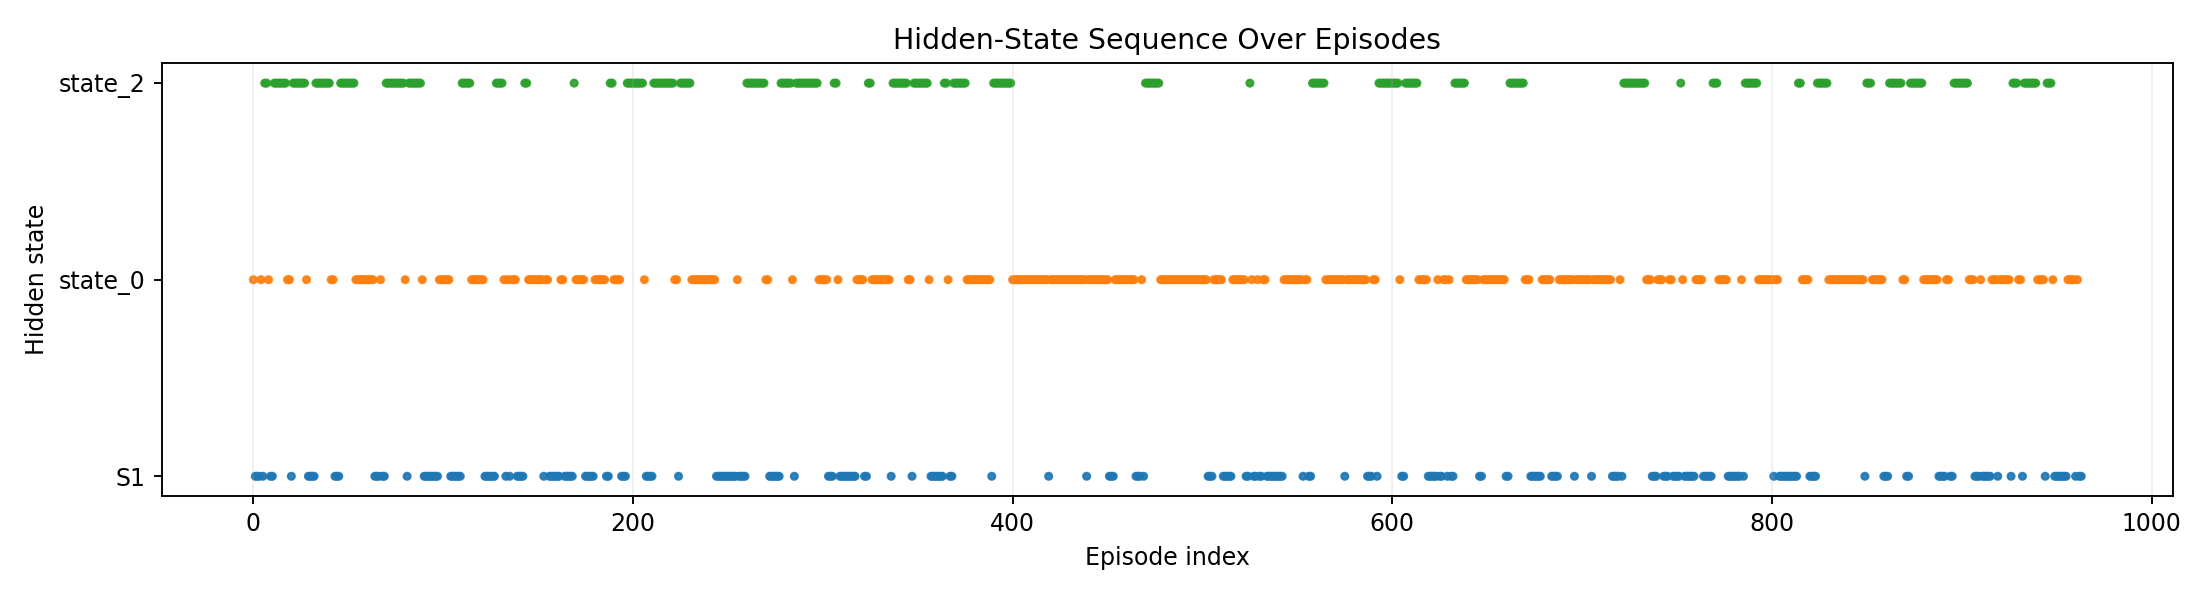

Showing: /Users/dmitryaleshkin/Documents/hidden-patterns-combat/artifacts/demo_run/plots/state_probability_profile.png


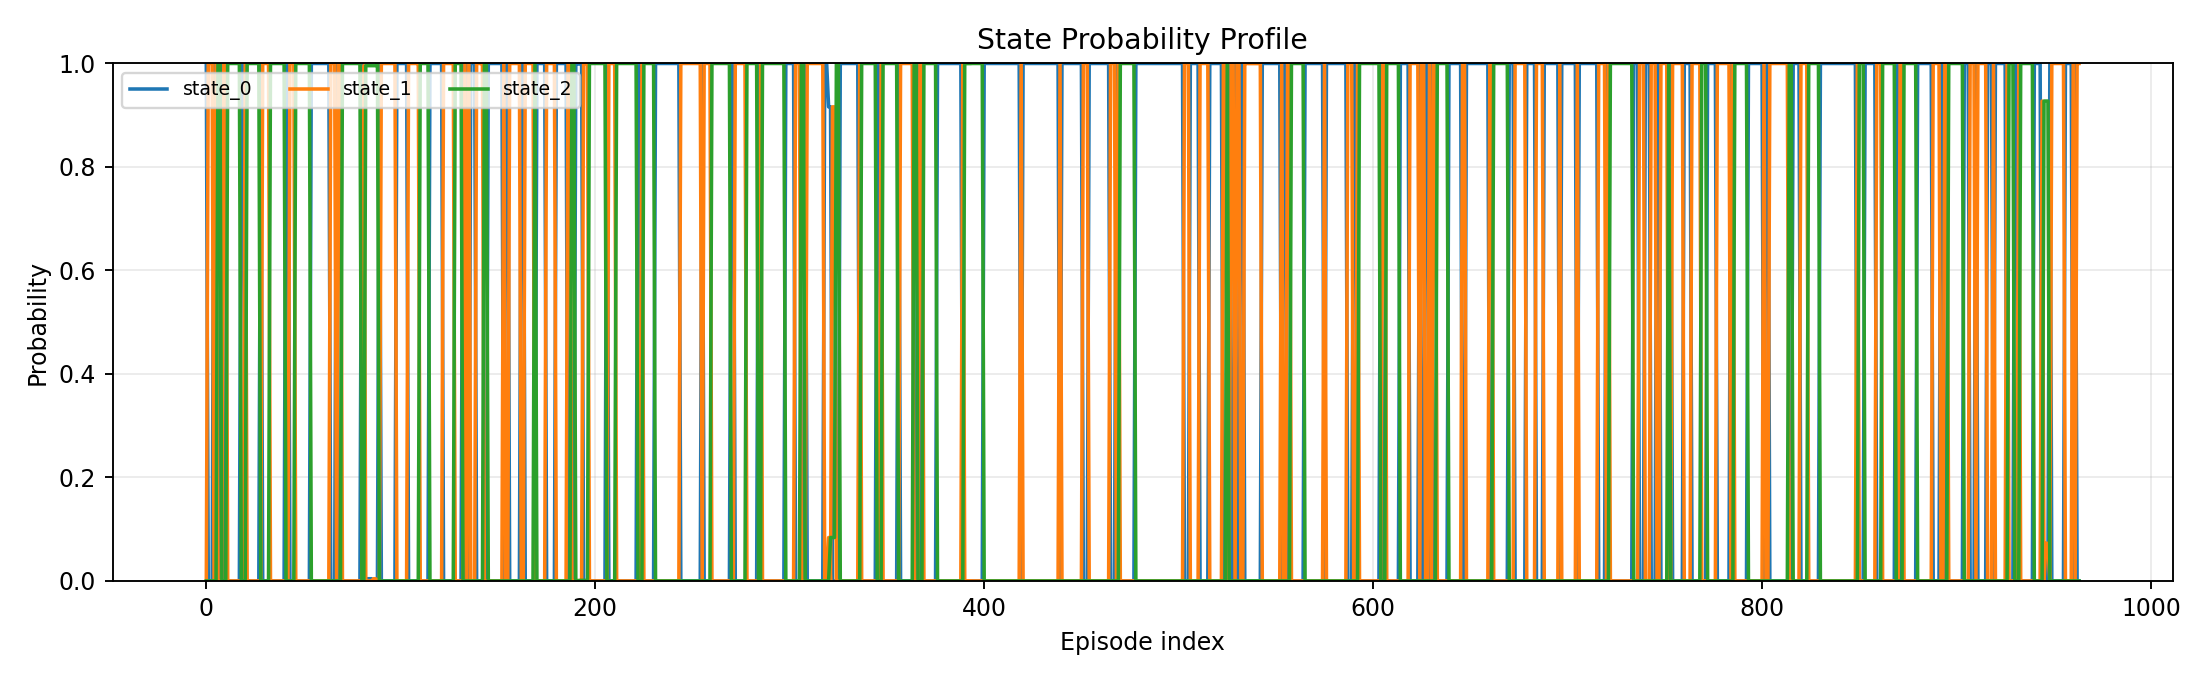

Showing: /Users/dmitryaleshkin/Documents/hidden-patterns-combat/artifacts/demo_run/plots/transition_distribution.png


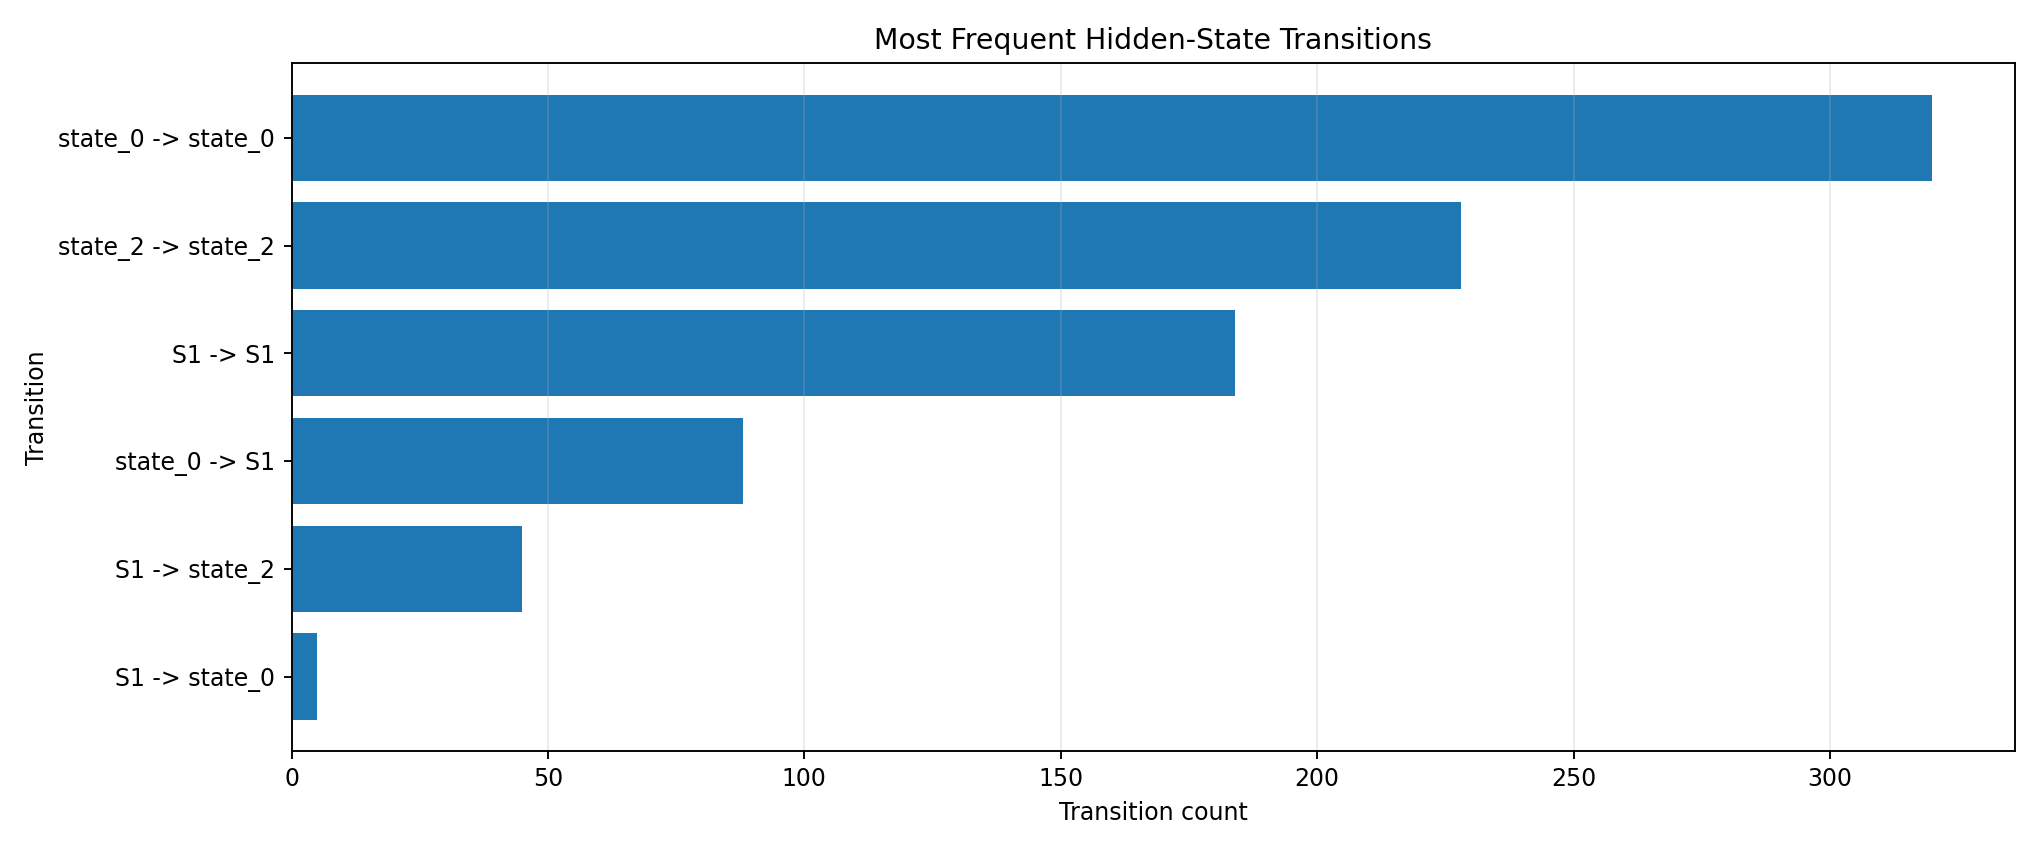

Showing: /Users/dmitryaleshkin/Documents/hidden-patterns-combat/artifacts/demo_run/plots/athlete_comparative_profile.png


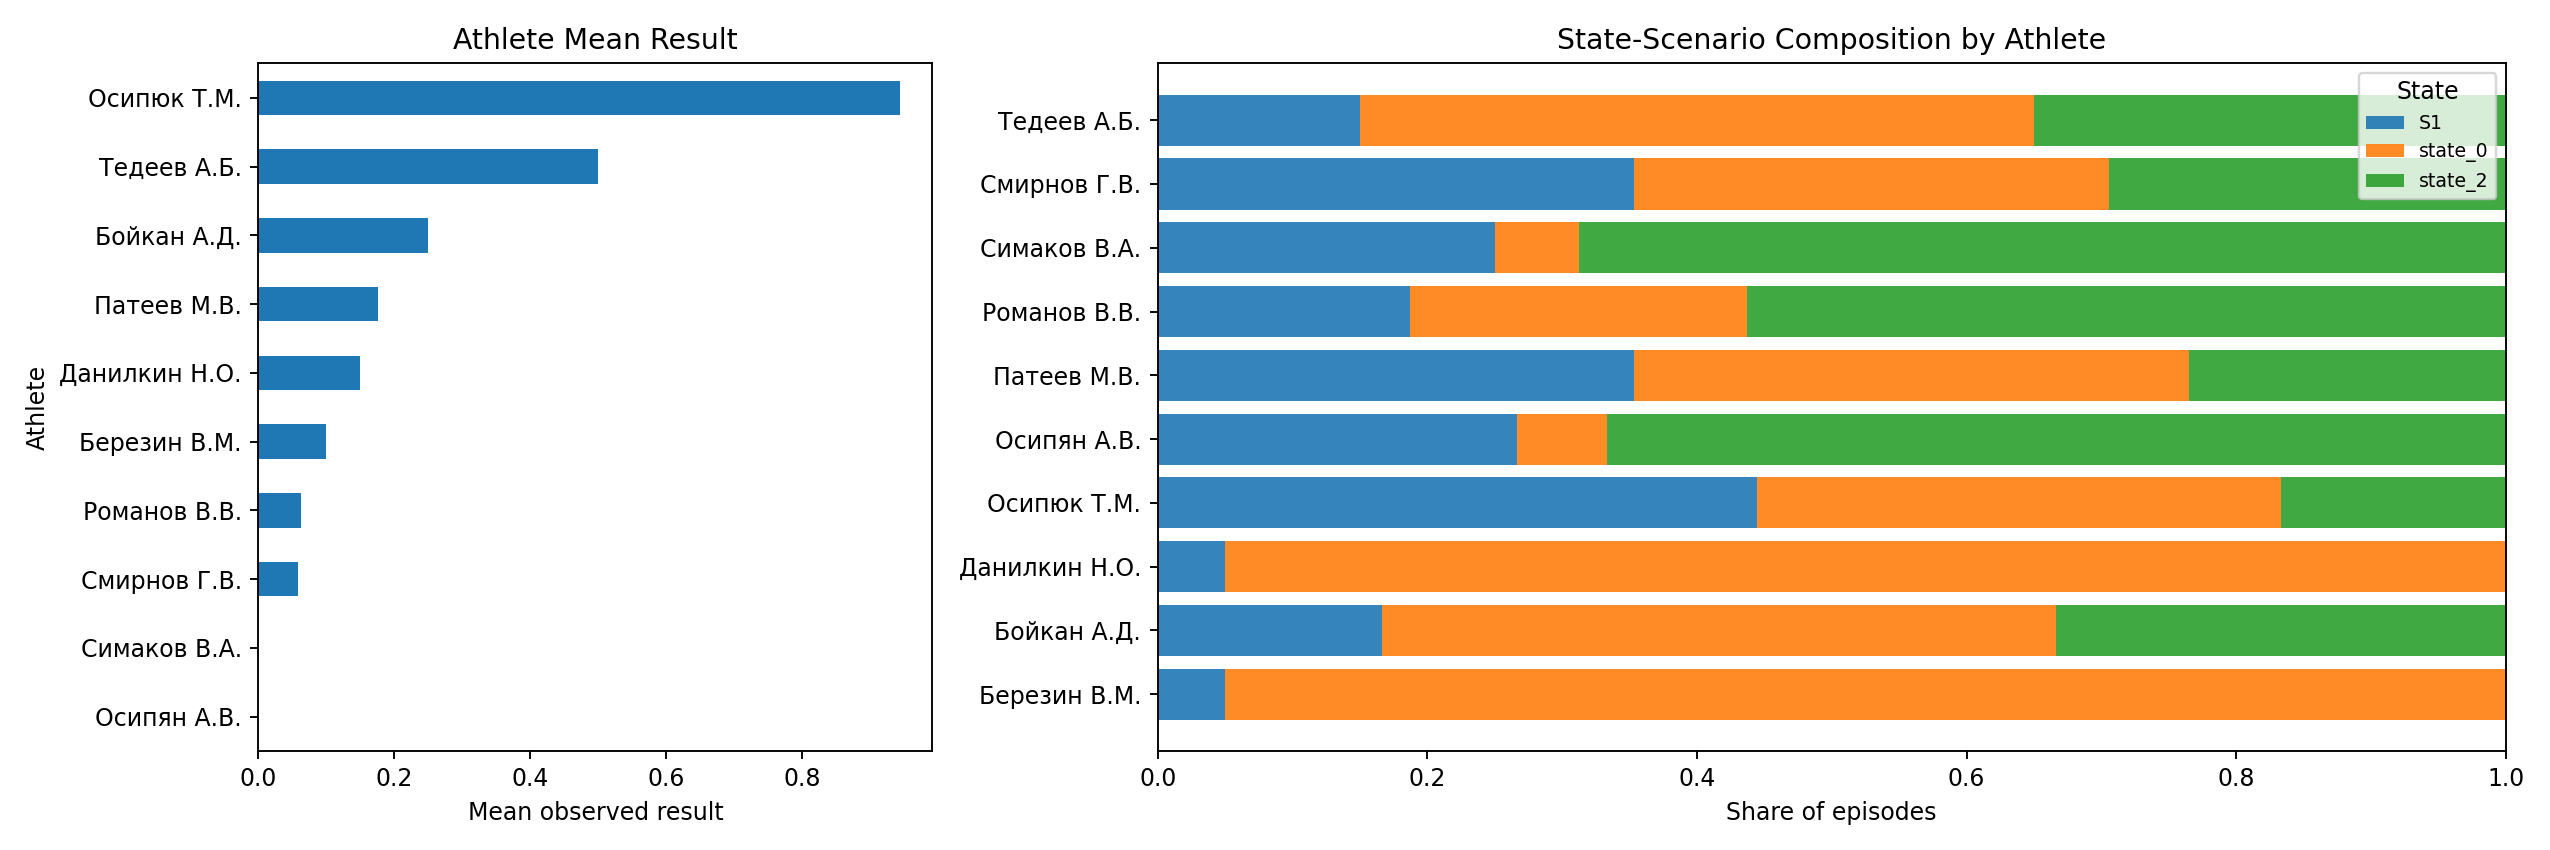

Showing: /Users/dmitryaleshkin/Documents/hidden-patterns-combat/artifacts/demo_run/plots/scenario_success_frequencies.png


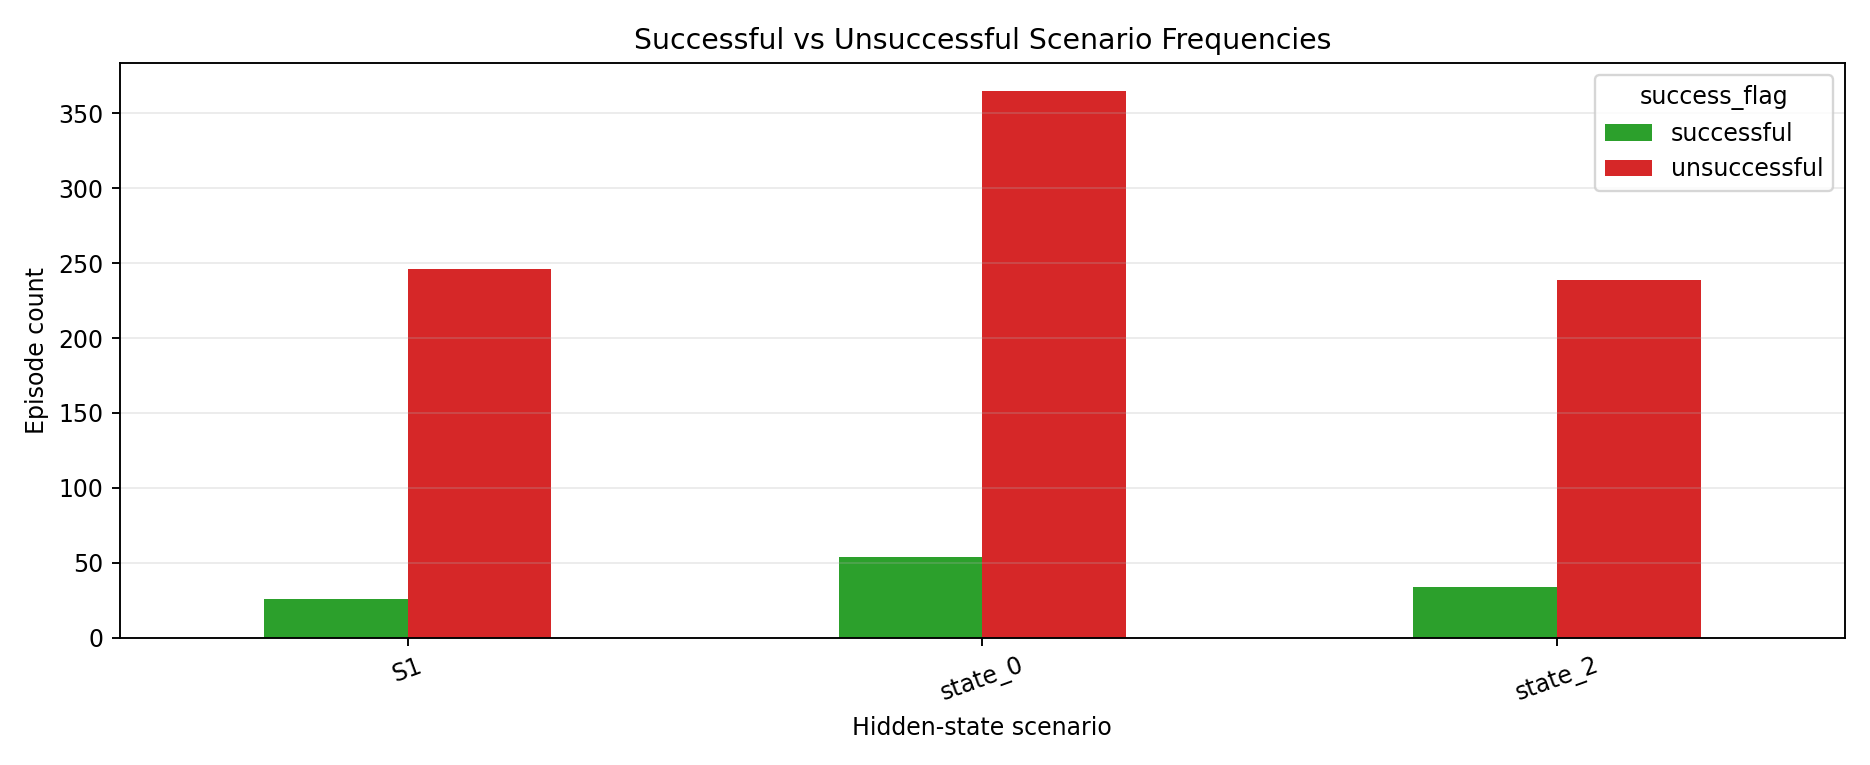

In [5]:
from IPython.display import Image, display

plots_dir = OUTPUT_DIR / "plots"
expected_plots = [
    "hidden_state_sequence.png",
    "state_probability_profile.png",
    "transition_distribution.png",
    "athlete_comparative_profile.png",
    "scenario_success_frequencies.png",
]

shown = set()

if plots_dir.exists():
    for name in expected_plots:
        path = plots_dir / name
        if path.exists():
            print(f"Showing: {path}")
            display(Image(filename=str(path)))
            shown.add(path.name)
        else:
            print(f"Missing plot (skip): {path}")

    for extra_path in sorted(plots_dir.glob("*.png")):
        if extra_path.name not in shown:
            print(f"Showing extra plot: {extra_path}")
            display(Image(filename=str(extra_path)))
else:
    print(f"Plots directory not found: {plots_dir}")


In [6]:
print("Run completed. Artifacts:")
print(f"- Model: {MODEL_PATH}")
print(f"- Diagnostics: {OUTPUT_DIR / 'diagnostics'}")
print(f"- Plots: {OUTPUT_DIR / 'plots'}")
print(f"- Report: {OUTPUT_DIR / 'reports' / 'full_cycle_report.md'}")


Run completed. Artifacts:
- Model: /Users/dmitryaleshkin/Documents/hidden-patterns-combat/artifacts/demo_run/models/hmm_model.pkl
- Diagnostics: /Users/dmitryaleshkin/Documents/hidden-patterns-combat/artifacts/demo_run/diagnostics
- Plots: /Users/dmitryaleshkin/Documents/hidden-patterns-combat/artifacts/demo_run/plots
- Report: /Users/dmitryaleshkin/Documents/hidden-patterns-combat/artifacts/demo_run/reports/full_cycle_report.md
